In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, balanced_accuracy_score, precision_recall_curve, roc_curve, auc



1. Відкрити та зчитати дані з наданого файлу.

In [12]:
data = pd.read_csv("KM-32-1.csv")
data 

,GT,Model_1_0,Model_2_1
0,1,0.014745,0.996526
1,0,0.999735,0.003289
2,0,0.999786,0.125449
3,0,0.999695,0.000858
4,1,0.022115,0.786606
...,...,...,...
4395,0,0.999753,0.125449
4396,0,0.999777,0.125449
4397,0,0.909023,0.159557
4398,0,0.999737,0.125999


2. Визначити збалансованість набору даних. Вивести кількість об’єктів
кожного класу.

In [13]:
data["GT"].value_counts()

GT
1    2200
0    2200
Name: count, dtype: int64

Датасет є збалансованим, бо кількість класів 0 та 1 рівна.

3.

а) Обчислити всі метрики (Accuracy, Precision, Recall, F-Scores,
Matthews Correlation Coefficient, Balanced Accuracy, Youden’s J
statistics, Area Under Curve for Precision-Recall Curve, Area
Under Curve for Receiver Operation Curve) для кожної моделі при
різних значеннях порогу класифікатора (крок зміни порогу
обрати самостійно).

In [ ]:
thresholds = np.linspace(0, 1, 21)

results_1 = []
results_2 = []
temp = pd.DataFrame()

# виправлення цільової змінної
data["Model_1_0"] = 1 - data["Model_1_0"]

precision_1, recall_1, thresholds_pr_1 = precision_recall_curve(data["GT"], data["Model_1_0"])
fpr_1, tpr_1, thresholds_roc_1 = roc_curve(data["GT"], data["Model_1_0"])

precision_2, recall_2, thresholds_pr_2 = precision_recall_curve(data["GT"], data["Model_2_1"])
fpr_2, tpr_2, thresholds_roc_2 = roc_curve(data["GT"], data["Model_2_1"])

for t in thresholds:
  temp["Class_1"] = (data["Model_1_0"] > t).astype(np.int32)
  
  results_1.append({
    "threshold": t,
    "accuracy": accuracy_score(data["GT"], temp["Class_1"]),
    "precision": precision_score(data["GT"], temp["Class_1"], zero_division=0),
    "recall": recall_score(data["GT"], temp["Class_1"]),
    "F-scores": f1_score(data["GT"], temp["Class_1"]),
    "matthews cor coef": matthews_corrcoef(data["GT"], temp["Class_1"]),
    "balanced accuracy score": balanced_accuracy_score(data["GT"], temp["Class_1"]),
    "youden's J statistics": (recall_score(data["GT"], temp["Class_1"], pos_label=1) + recall_score(data["GT"], temp["Class_1"], pos_label=0) - 1),
    "area under PRC": auc(recall_1, precision_1),
    "area under ROC": auc(fpr_1, tpr_1)
  })
  
  temp["Class_2"] = (data["Model_2_1"] > t).astype(np.int32)
 
  results_2.append({
    "threshold": t,
    "accuracy": accuracy_score(data["GT"], temp["Class_2"]),
    "precision": precision_score(data["GT"], temp["Class_2"], zero_division=0),
    "recall": recall_score(data["GT"], temp["Class_2"]),
    "F-scores": f1_score(data["GT"], temp["Class_2"]),
    "matthews cor coef": matthews_corrcoef(data["GT"], temp["Class_2"]),
    "balanced accuracy score": balanced_accuracy_score(data["GT"], temp["Class_2"]),
    "youden's J statistics": (recall_score(data["GT"], temp["Class_2"], pos_label=1) + recall_score(data["GT"], temp["Class_2"], pos_label=0) - 1),
    "area under PRC": auc(recall_2, precision_2),
    "area under ROC": auc(fpr_2, tpr_2)
  })

df_res_1 = pd.DataFrame(results_1)
df_res_2 = pd.DataFrame(results_2)

display(df_res_1)
df_res_2

,threshold,accuracy,precision,recall,F-scores,matthews cor coef,balanced accuracy score,youden's J statistics,area under PRC,area under ROC
0,0.00,0.500000,0.500000,1.000000,0.666667,0.000000,0.500000,0.000000,0.993851,0.996785
1,0.05,0.977955,0.958970,0.998636,0.978401,0.956728,0.977955,0.955909,0.993851,0.996785
2,0.10,0.982955,0.968681,0.998182,0.983210,0.966357,0.982955,0.965909,0.993851,0.996785
3,0.15,0.984773,0.972112,0.998182,0.984974,0.969894,0.984773,0.969545,0.993851,0.996785
4,0.20,0.985682,0.975523,0.996364,0.985833,0.971585,0.985682,0.971364,0.993851,0.996785
5,0.25,0.987500,0.979008,0.996364,0.987610,0.975153,0.987500,0.975000,0.993851,0.996785
6,0.30,0.988636,0.981200,0.996364,0.988724,0.977389,0.988636,0.977273,0.993851,0.996785
7,0.35,0.988636,0.981631,0.995909,0.988718,0.977376,0.988636,0.977273,0.993851,0.996785
8,0.40,0.989318,0.982952,0.995909,0.989388,0.978721,0.989318,0.978636,0.993851,0.996785
9,0.45,0.990000,0.984277,0.995909,0.990059,0.980068,0.990000,0.980000,0.993851,0.996785


,threshold,accuracy,precision,recall,F-scores,matthews cor coef,balanced accuracy score,youden's J statistics,area under PRC,area under ROC
0,0.00,0.540227,0.520957,1.000000,0.685038,0.204727,0.540227,0.080455,0.996758,0.997038
1,0.05,0.747273,0.664350,0.999545,0.798185,0.572798,0.747273,0.494545,0.996758,0.997038
2,0.10,0.812273,0.727785,0.997727,0.841641,0.672517,0.812273,0.624545,0.996758,0.997038
3,0.15,0.970000,0.945306,0.997727,0.970809,0.941449,0.970000,0.940000,0.996758,0.997038
4,0.20,0.991136,0.986931,0.995455,0.991174,0.982309,0.991136,0.982273,0.996758,0.997038
5,0.25,0.991136,0.986931,0.995455,0.991174,0.982309,0.991136,0.982273,0.996758,0.997038
6,0.30,0.991136,0.986931,0.995455,0.991174,0.982309,0.991136,0.982273,0.996758,0.997038
7,0.35,0.991364,0.987376,0.995455,0.991399,0.982760,0.991364,0.982727,0.996758,0.997038
8,0.40,0.991136,0.987370,0.995000,0.991170,0.982302,0.991136,0.982273,0.996758,0.997038
9,0.45,0.991136,0.987370,0.995000,0.991170,0.982302,0.991136,0.982273,0.996758,0.997038


b) Збудувати на одному графіку в одній координатній системі
(величина порогу; значення метрики) графіки усіх обчислених
метрик, відмітивши певним чином максимальне значення кожної
з них.

C:\Users\rosti\AppData\Local\Temp\ipykernel_21844\1490268321.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_thresholds_1 = pd.concat([


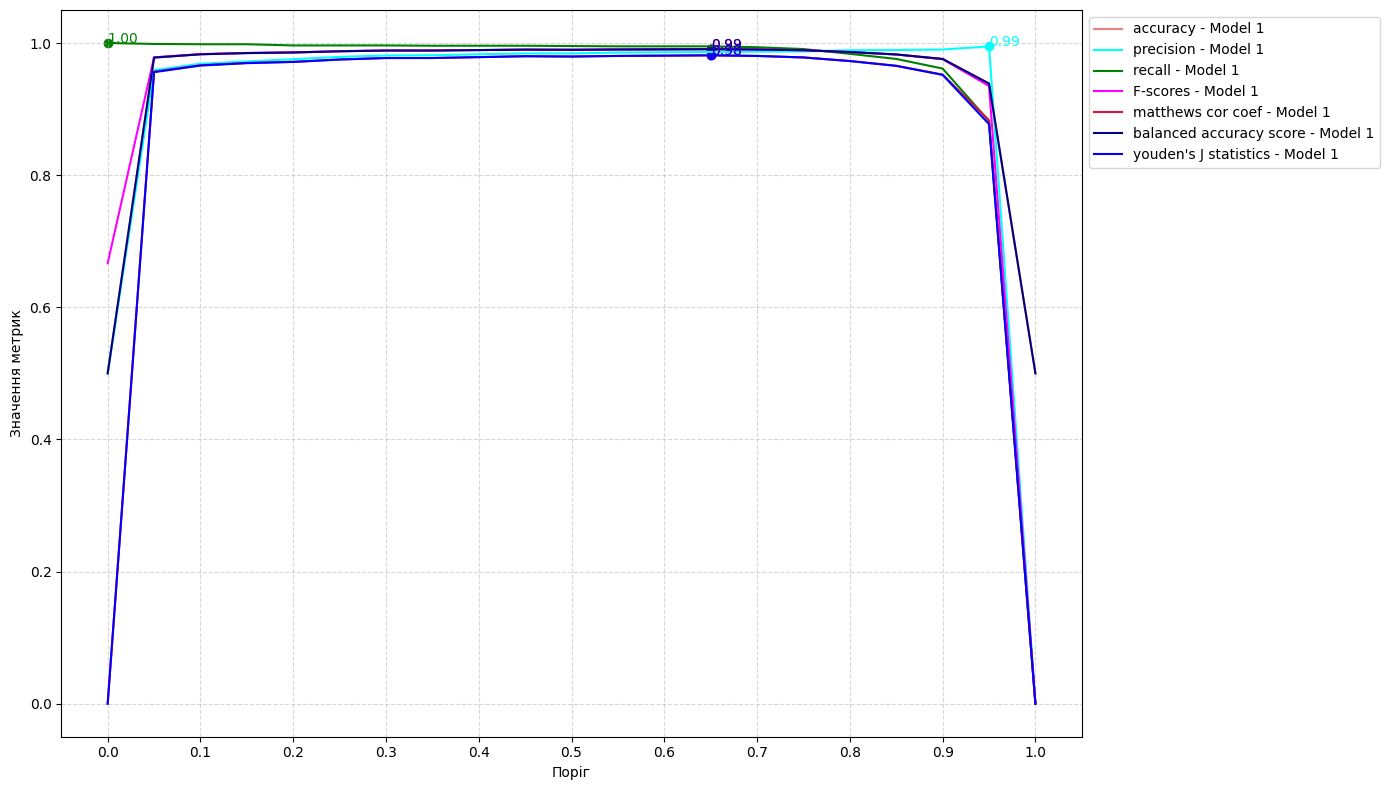

C:\Users\rosti\AppData\Local\Temp\ipykernel_21844\1490268321.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_thresholds_2 = pd.concat([


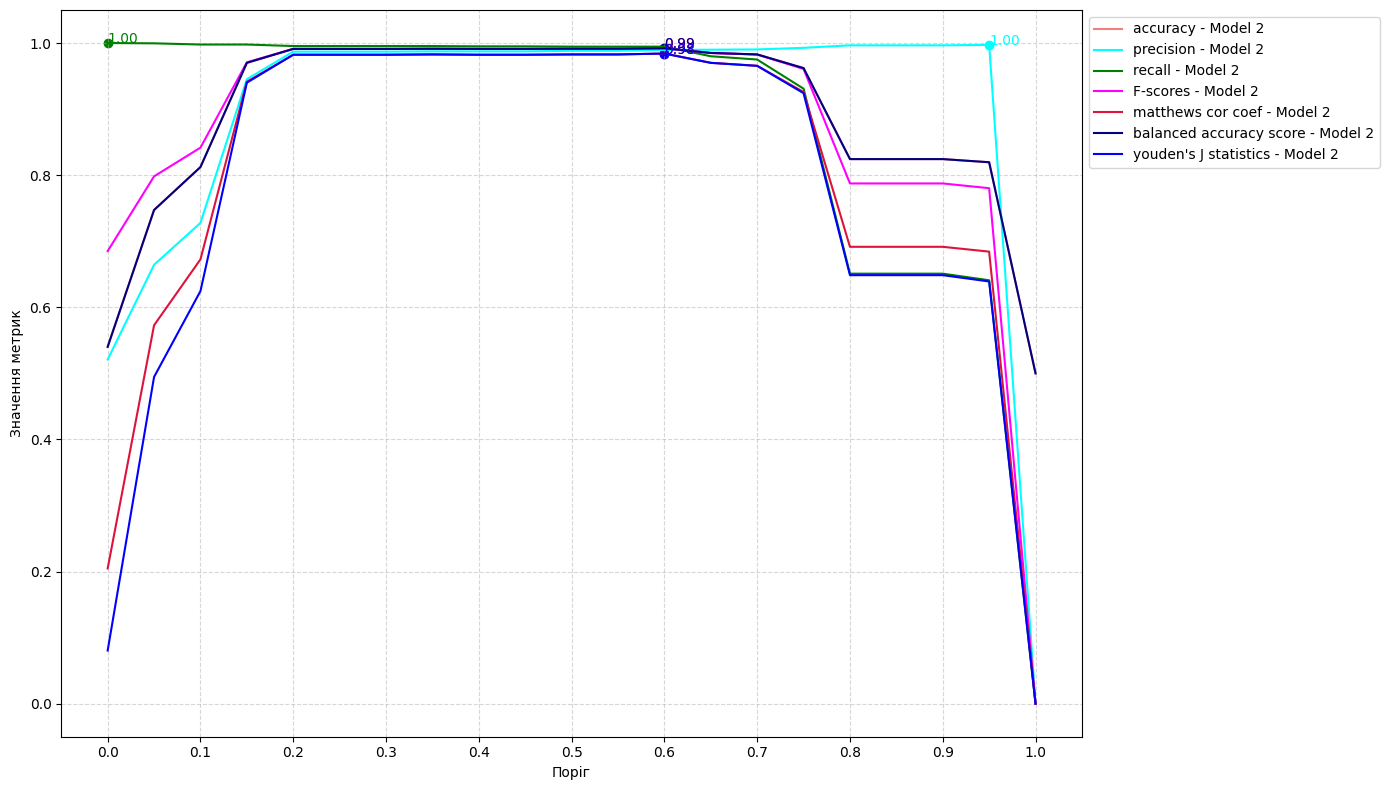

In [15]:
metrics = ["accuracy", "precision", "recall", "F-scores", "matthews cor coef", "balanced accuracy score", "youden's J statistics"]
colors = ["lightcoral", "cyan", "green", "magenta", "crimson", "navy", "blue"]

optimal_thresholds_1 = pd.DataFrame(columns=["metric", "threshold"])
optimal_thresholds_2 = pd.DataFrame(columns=["metric", "threshold"])

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metrics):
	plt.plot(df_res_1["threshold"], df_res_1[metric], label=f"{metric} - Model 1", color=colors[i])
	
	idx_max1 = df_res_1[metric].idxmax()
	best_thresh1 = df_res_1["threshold"][idx_max1]
	
	optimal_thresholds_1 = pd.concat([
			optimal_thresholds_1,
			pd.DataFrame([{"metric": metric, "threshold": best_thresh1}])
	], ignore_index=True)
 
	plt.scatter(df_res_1["threshold"][idx_max1], df_res_1[metric][idx_max1], color=colors[i])
	plt.text(df_res_1["threshold"][idx_max1], df_res_1[metric][idx_max1], f"{df_res_1[metric][idx_max1]:.2f}", color=colors[i])
 
plt.xlabel("Поріг")
plt.xticks(np.linspace(0, 1, 11))
plt.ylabel("Значення метрик")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metrics):
	plt.plot(df_res_2["threshold"], df_res_2[metric], label=f"{metric} - Model 2", color=colors[i])

	idx_max2 = df_res_2[metric].idxmax()
	best_thresh2 = df_res_2["threshold"][idx_max2]
	
	optimal_thresholds_2 = pd.concat([
			optimal_thresholds_2,
			pd.DataFrame([{"model": "Model 2", "metric": metric, "threshold": best_thresh2}])
	], ignore_index=True)
    
	plt.scatter(df_res_2["threshold"][idx_max2], df_res_2[metric][idx_max2], color=colors[i])
	plt.text(df_res_2["threshold"][idx_max2], df_res_2[metric][idx_max2], f"{df_res_2[metric][idx_max2]:.2f}", color=colors[i])

plt.xlabel("Поріг")
plt.xticks(np.linspace(0, 1, 11))
plt.ylabel("Значення метрик")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


c) Збудувати в координатах (значення оцінки класифікаторів;
кількість об’єктів кожного класу) окремі для кожного класу
графіки кількості об’єктів та відмітити вертикальними лініями
оптимальні пороги відсічення для кожної метрики.

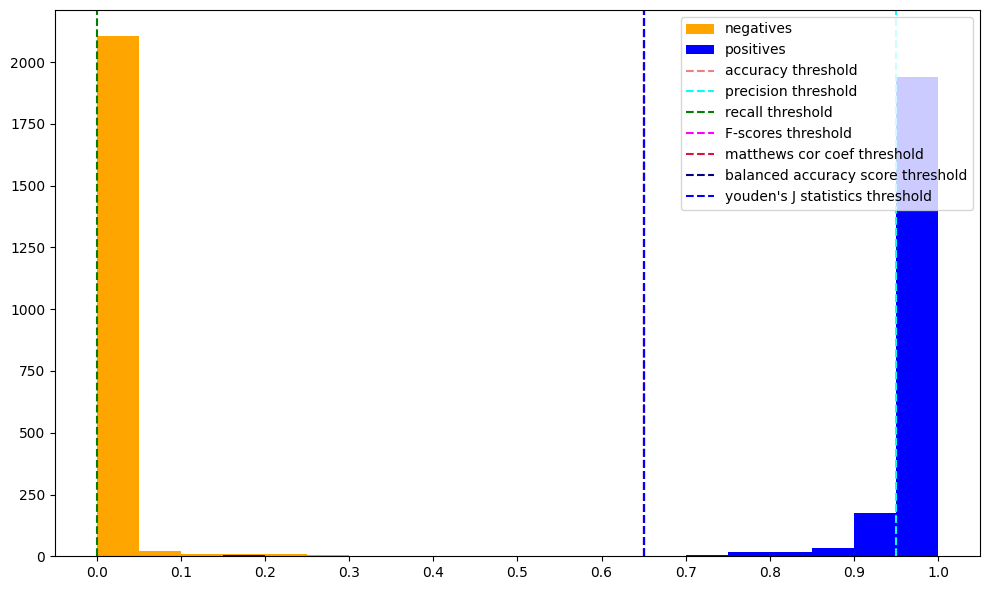

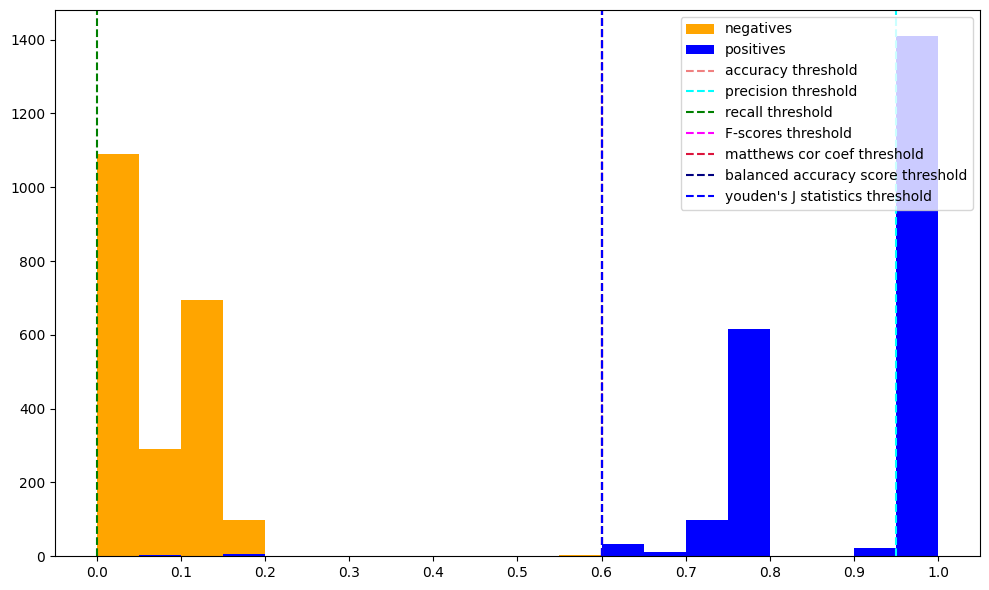

In [16]:
plt.figure(figsize=(10,6))

plt.hist(data[data["GT"]==0]["Model_1_0"], bins=thresholds, color="orange", label="negatives")
plt.hist(data[data["GT"]==1]["Model_1_0"], bins=thresholds, color="blue", label="positives")

for i, row in optimal_thresholds_1.iterrows():
    metric = row["metric"]
    threshold = row["threshold"] 
    plt.axvline(x=threshold, color=colors[i], linestyle='--', label=f"{metric} threshold")
 
plt.xticks(np.linspace(0, 1, 11))
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(10,6))

plt.hist(data[data["GT"]==0]["Model_2_1"], bins=thresholds, color="orange", label="negatives")
plt.hist(data[data["GT"]==1]["Model_2_1"], bins=thresholds, color="blue", label="positives")
for i, row in optimal_thresholds_2.iterrows():
    metric = row["metric"]
    threshold = row["threshold"] 
    plt.axvline(x=threshold, color=colors[i], linestyle='--', label=f"{metric} threshold")
plt.legend()
plt.xticks(np.linspace(0, 1, 11))
plt.tight_layout()
plt.show()


d) Збудувати для кожного класифікатору PR-криву та ROC-криву,
показавши графічно на них значення оптимального порогу.

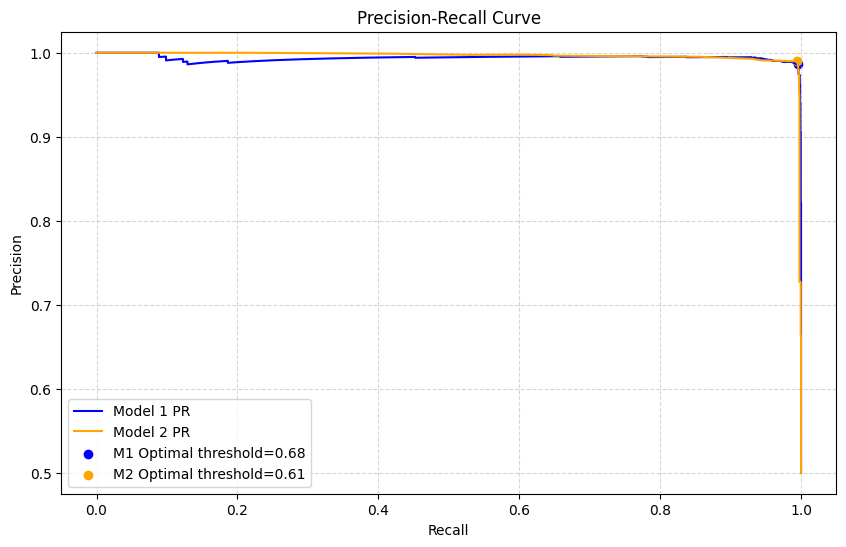

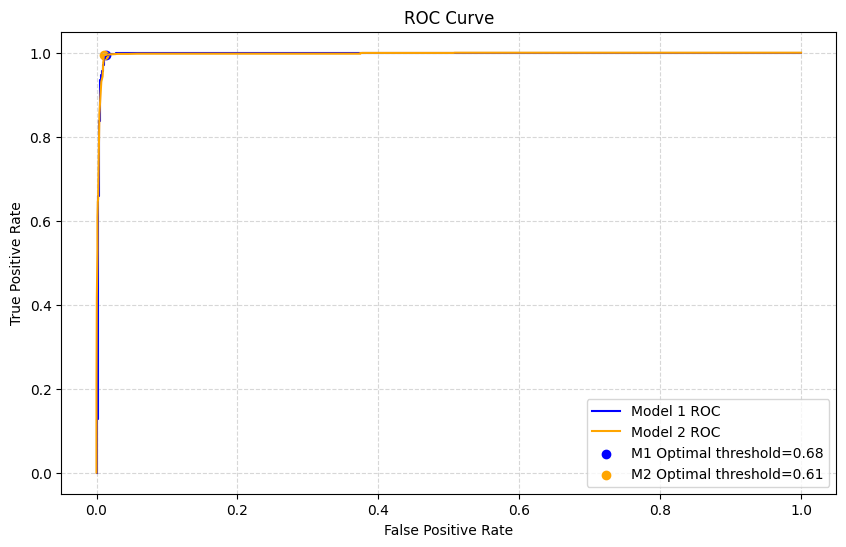

In [17]:
idx_opt1_pr = np.argmin(np.sqrt((1 - recall_1)**2 + (1 - precision_1)**2))
idx_opt2_pr = np.argmin(np.sqrt((1 - recall_2)**2 + (1 - precision_2)**2))

threshold_opt1_pr = thresholds_pr_1[idx_opt1_pr] if idx_opt1_pr < len(thresholds_pr_1) else thresholds_pr_1[-1]
threshold_opt2_pr = thresholds_pr_2[idx_opt2_pr] if idx_opt2_pr < len(thresholds_pr_2) else thresholds_pr_2[-1]

plt.figure(figsize=(10,6))
plt.plot(recall_1, precision_1, label="Model 1 PR", color="blue")
plt.plot(recall_2, precision_2, label="Model 2 PR", color="orange")

plt.scatter(recall_1[idx_opt1_pr], precision_1[idx_opt1_pr], color="blue", label=f"M1 Optimal threshold={threshold_opt1_pr:.2f}")
plt.scatter(recall_2[idx_opt2_pr], precision_2[idx_opt2_pr], color="orange", label=f"M2 Optimal threshold={threshold_opt2_pr:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

idx_opt1_roc = np.argmin(np.sqrt((0 - fpr_1)**2 + (1 - tpr_1)**2))
idx_opt2_roc = np.argmin(np.sqrt((0 - fpr_2)**2 + (1 - tpr_2)**2))

threshold_opt1_roc = thresholds_roc_1[idx_opt1_roc]
threshold_opt2_roc = thresholds_roc_2[idx_opt2_roc]

plt.figure(figsize=(10,6))
plt.plot(fpr_1, tpr_1, label="Model 1 ROC", color="blue")
plt.plot(fpr_2, tpr_2, label="Model 2 ROC", color="orange")
plt.scatter(fpr_1[idx_opt1_roc], tpr_1[idx_opt1_roc], color="blue", label=f"M1 Optimal threshold={threshold_opt1_roc:.2f}")
plt.scatter(fpr_2[idx_opt2_roc], tpr_2[idx_opt2_roc], color="orange", label=f"M2 Optimal threshold={threshold_opt2_roc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


4. Зробити висновки щодо якості моделей, визначити кращу модель. <br>
	Якщо дивитись на пораховані метрики до першої моделі, то видно, що навіть з найкращим порогом, не досягається і половина максимального значення метрики. Також варто звернути увагу на коефіцієнт Метью та статистику Йодена - в найкращому випадку вони є 0, а це означає, що в найкращому випадку модель класифікує з таким самим успіхом, як випадковий генератор. А при інших порогах вони взагалі є від'ємними, що означає, що класифікатор помиляється неправильно частише, ніж правильно. Це значить, що модель працює дуже неякісно. А от друга модель при виставленні порогу 0.6 класифікує майже ідеально - кожна метрика має значення, близьке до 1, що є максимальним.

5. Створити новий набір даних, прибравши з початкового набору
(50 + 10К)% об’єктів класу 1, вибраних випадковим чином. Параметр К
представляє собою залишок від ділення місяця народження студента на
чотири та має визначатися в програмі на основі дати народження
студента, яка задана в програмі у вигляді текстової змінної формату
‘DD-MM’.

In [18]:
birthday = "03-11"

month = int(birthday.split('-')[1])
K = month % 4
percent = 50 + 10*K

class_1 = data[data["GT"] == 1]
remove_amount = int(len(class_1) * percent / 100)

removed_rows = np.random.choice(class_1.index, size=remove_amount, replace=False)
data_new = data.drop(removed_rows)
data_new = data_new.reset_index(drop=True)

display(data_new)

,GT,Model_1_0,Model_2_1
0,0,0.000265,0.003289
1,0,0.000214,0.125449
2,0,0.000305,0.000858
3,0,0.598145,0.159557
4,0,0.000196,0.054026
...,...,...,...
2635,0,0.000247,0.125449
2636,0,0.000223,0.125449
2637,0,0.090977,0.159557
2638,0,0.000263,0.125999


6. Вивести відсоток видалених об’єктів класу 1 та кількість елементів
кожного класу після видалення.

In [19]:
print(f"Кількість видалених: {percent}%")
data_new["GT"].value_counts()

Кількість видалених: 80%


GT
0    2200
1     440
Name: count, dtype: int64

7. Виконати дії п.3 для нового набору даних.

,threshold,accuracy,precision,recall,F-scores,matthews cor coef,balanced accuracy score,youden's J statistics,area under PRC,area under ROC
0,0.00,0.166667,0.166667,1.000000,0.285714,0.000000,0.500000,0.000000,0.970404,0.99674
1,0.05,0.964015,0.823640,0.997727,0.902364,0.886636,0.977500,0.955000,0.970404,0.99674
2,0.10,0.972348,0.860511,0.995455,0.923077,0.909904,0.981591,0.963182,0.970404,0.99674
3,0.15,0.975379,0.874251,0.995455,0.930925,0.918879,0.983409,0.966818,0.970404,0.99674
4,0.20,0.978030,0.888211,0.993182,0.937768,0.926606,0.984091,0.968182,0.970404,0.99674
5,0.25,0.981061,0.902893,0.993182,0.945887,0.936000,0.985909,0.971818,0.970404,0.99674
6,0.30,0.982955,0.912317,0.993182,0.951034,0.941981,0.987045,0.974091,0.970404,0.99674
7,0.35,0.982955,0.914046,0.990909,0.950927,0.941756,0.986136,0.972273,0.970404,0.99674
8,0.40,0.984091,0.919831,0.990909,0.954048,0.945401,0.986818,0.973636,0.970404,0.99674
9,0.45,0.985227,0.925690,0.990909,0.957190,0.949078,0.987500,0.975000,0.970404,0.99674


,threshold,accuracy,precision,recall,F-scores,matthews cor coef,balanced accuracy score,youden's J statistics,area under PRC,area under ROC
0,0.00,0.233712,0.178644,1.000000,0.303135,0.119886,0.540227,0.080455,0.982591,0.995059
1,0.05,0.578788,0.283226,0.997727,0.441206,0.372963,0.746364,0.492727,0.982591,0.995059
2,0.10,0.687879,0.347377,0.993182,0.514723,0.462631,0.810000,0.620000,0.982591,0.995059
3,0.15,0.950758,0.774823,0.993182,0.870518,0.850564,0.967727,0.935455,0.982591,0.995059
4,0.20,0.987500,0.937634,0.990909,0.963536,0.956532,0.988864,0.977727,0.982591,0.995059
5,0.25,0.987500,0.937634,0.990909,0.963536,0.956532,0.988864,0.977727,0.982591,0.995059
6,0.30,0.987500,0.937634,0.990909,0.963536,0.956532,0.988864,0.977727,0.982591,0.995059
7,0.35,0.987879,0.939655,0.990909,0.964602,0.957787,0.989091,0.978182,0.982591,0.995059
8,0.40,0.987879,0.939655,0.990909,0.964602,0.957787,0.989091,0.978182,0.982591,0.995059
9,0.45,0.987879,0.939655,0.990909,0.964602,0.957787,0.989091,0.978182,0.982591,0.995059


C:\Users\rosti\AppData\Local\Temp\ipykernel_21844\2046431944.py:63: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_thresholds_1 = pd.concat([


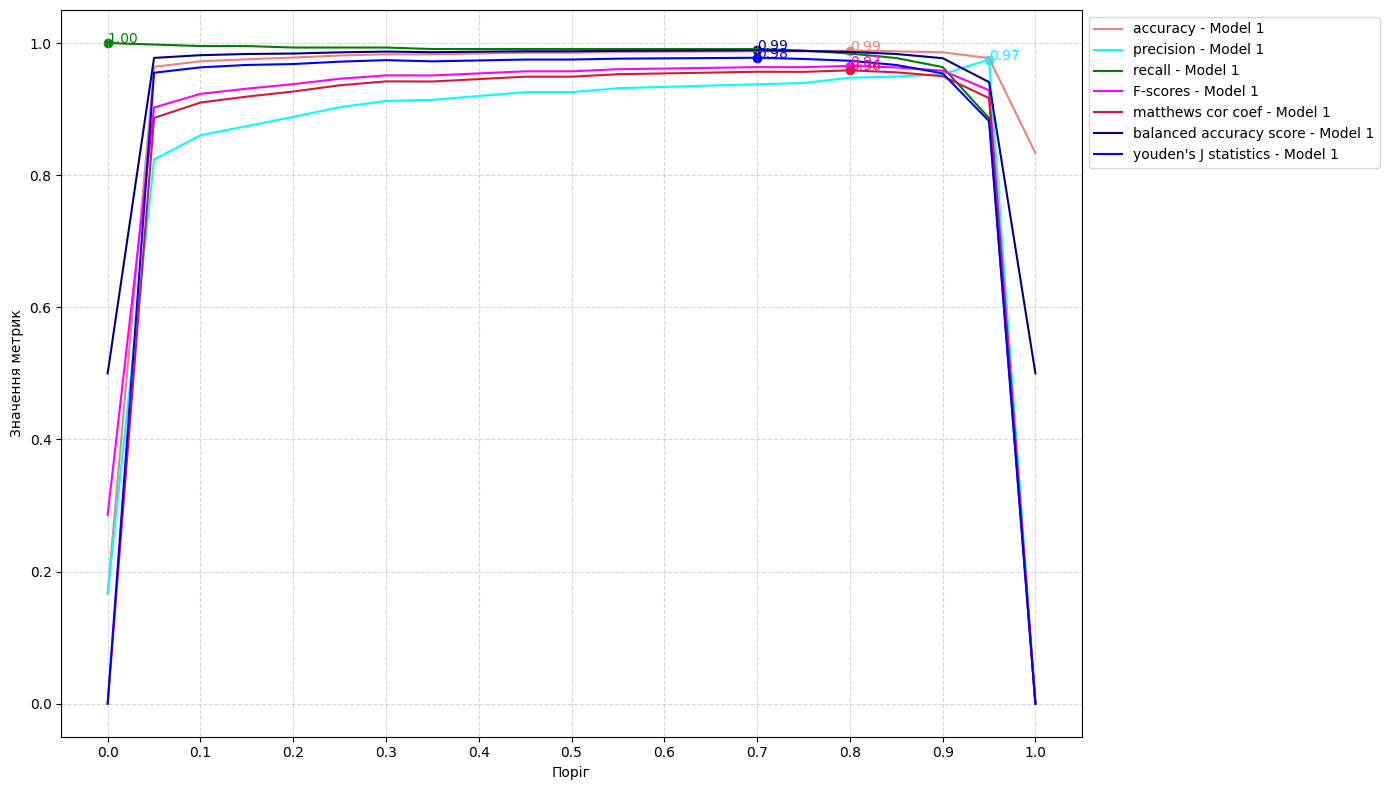

C:\Users\rosti\AppData\Local\Temp\ipykernel_21844\2046431944.py:87: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  optimal_thresholds_2 = pd.concat([


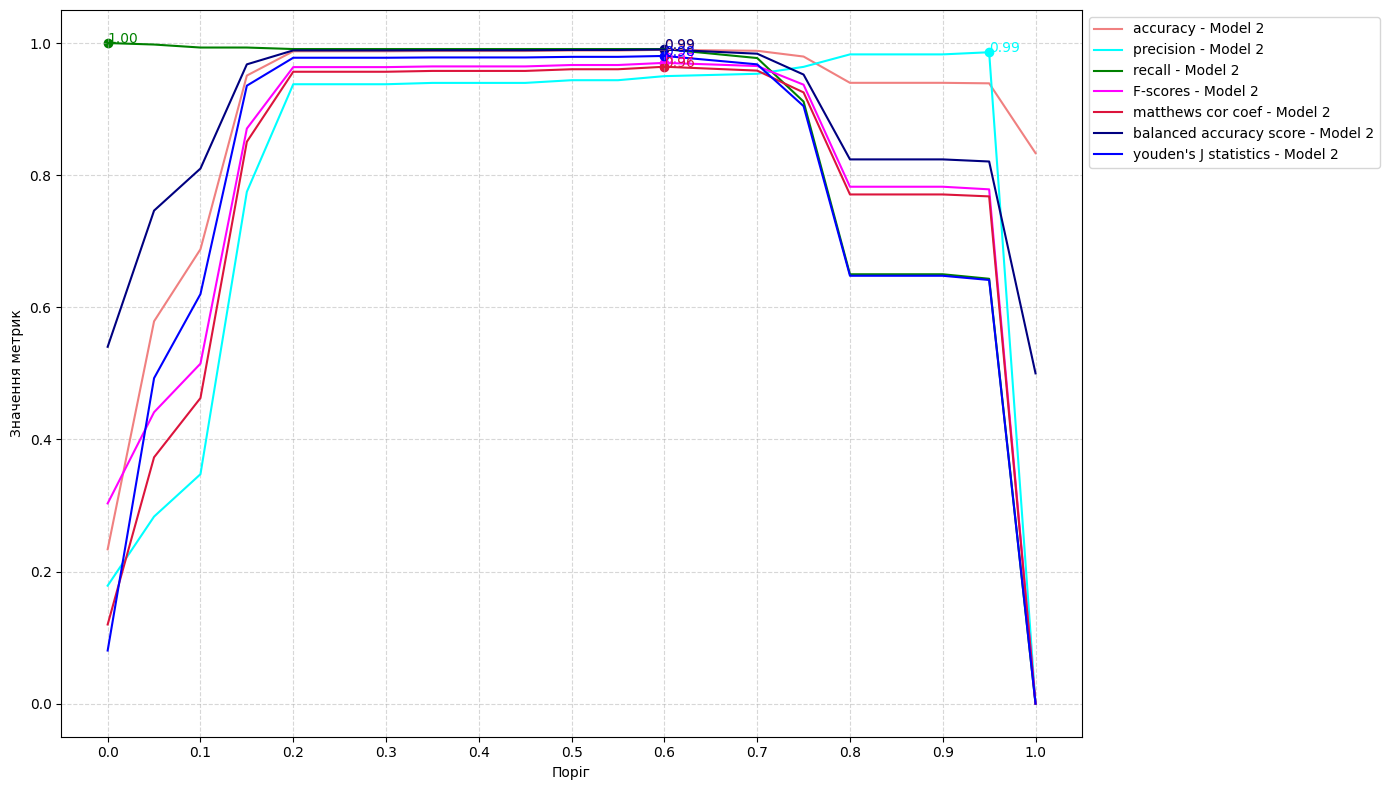

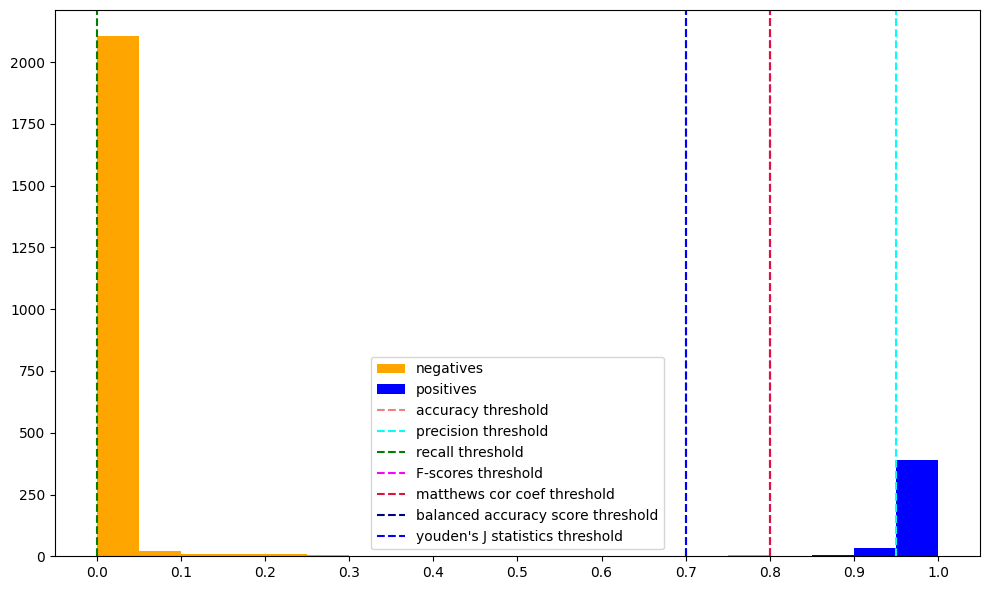

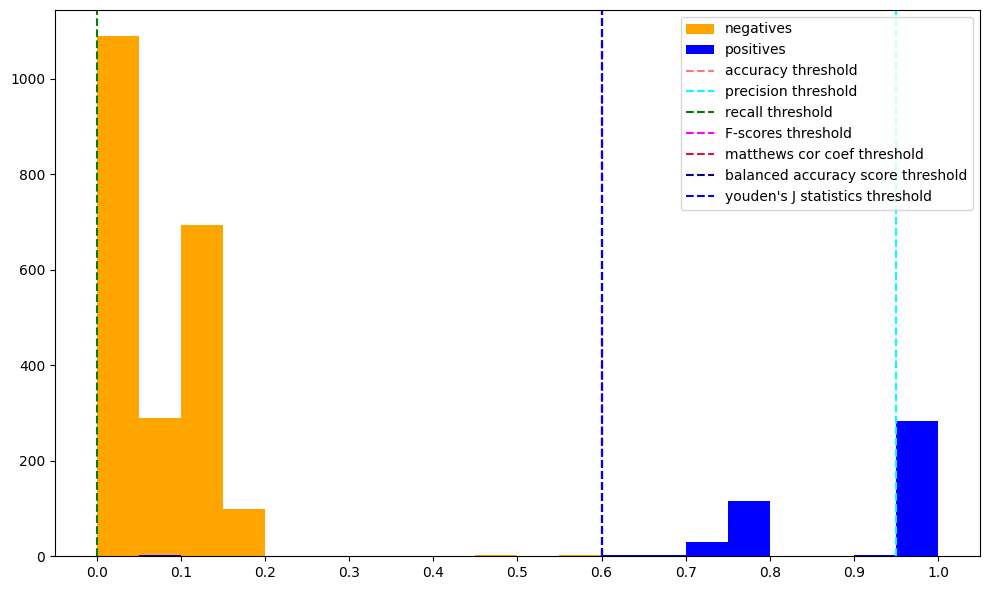

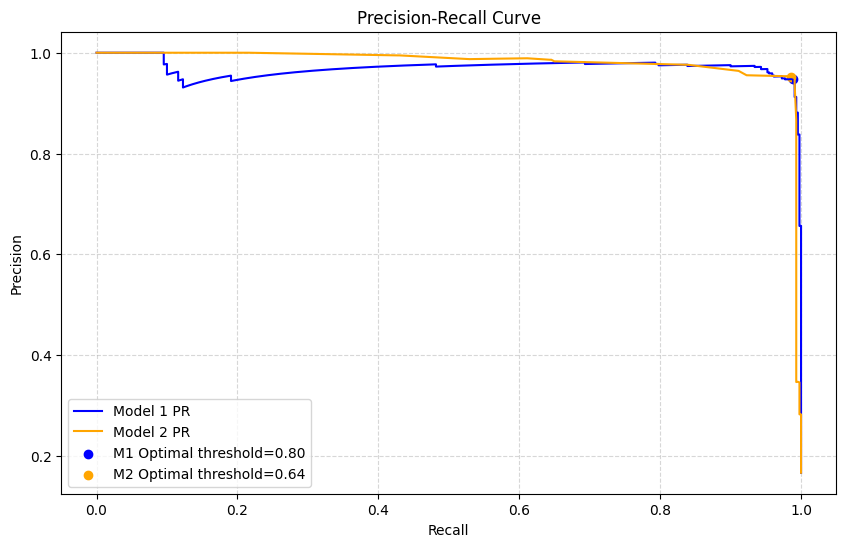

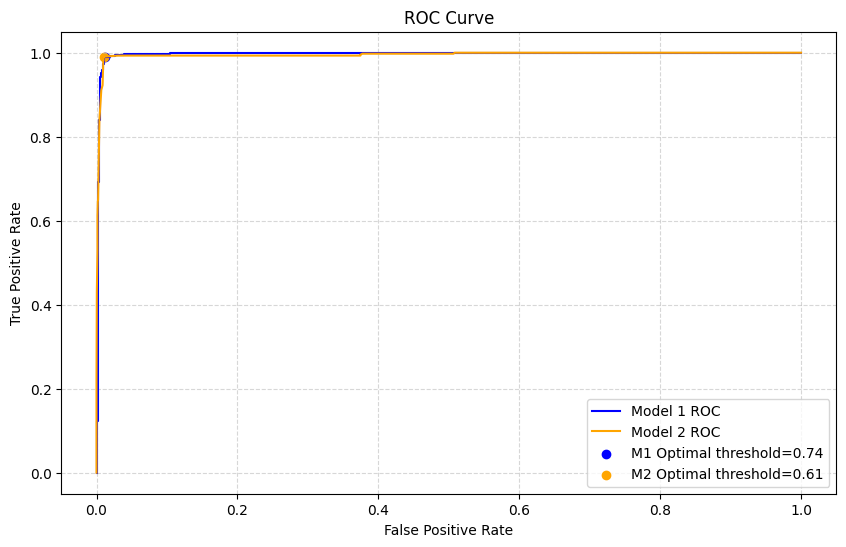

In [20]:
results_1 = []
results_2 = []
temp = pd.DataFrame()

precision_1, recall_1, thresholds_pr_1 = precision_recall_curve(data_new["GT"], data_new["Model_1_0"])
fpr_1, tpr_1, thresholds_roc_1 = roc_curve(data_new["GT"], data_new["Model_1_0"])

precision_2, recall_2, thresholds_pr_2 = precision_recall_curve(data_new["GT"], data_new["Model_2_1"])
fpr_2, tpr_2, thresholds_roc_2 = roc_curve(data_new["GT"], data_new["Model_2_1"])

for t in thresholds:
  temp["Class_1"] = (data_new["Model_1_0"] > t).astype(np.int32)
  
  results_1.append({
    "threshold": t,
    "accuracy": accuracy_score(data_new["GT"], temp["Class_1"]),
    "precision": precision_score(data_new["GT"], temp["Class_1"], zero_division=0),
    "recall": recall_score(data_new["GT"], temp["Class_1"]),
    "F-scores": f1_score(data_new["GT"], temp["Class_1"]),
    "matthews cor coef": matthews_corrcoef(data_new["GT"], temp["Class_1"]),
    "balanced accuracy score": balanced_accuracy_score(data_new["GT"], temp["Class_1"]),
    "youden's J statistics": (recall_score(data_new["GT"], temp["Class_1"], pos_label=1) + recall_score(data_new["GT"], temp["Class_1"], pos_label=0) - 1),
    "area under PRC": auc(recall_1, precision_1),
    "area under ROC": auc(fpr_1, tpr_1)
  })
  
  temp["Class_2"] = (data_new["Model_2_1"] > t).astype(np.int32)
 
  results_2.append({
    "threshold": t,
    "accuracy": accuracy_score(data_new["GT"], temp["Class_2"]),
    "precision": precision_score(data_new["GT"], temp["Class_2"], zero_division=0),
    "recall": recall_score(data_new["GT"], temp["Class_2"]),
    "F-scores": f1_score(data_new["GT"], temp["Class_2"]),
    "matthews cor coef": matthews_corrcoef(data_new["GT"], temp["Class_2"]),
    "balanced accuracy score": balanced_accuracy_score(data_new["GT"], temp["Class_2"]),
    "youden's J statistics": (recall_score(data_new["GT"], temp["Class_2"], pos_label=1) + recall_score(data_new["GT"], temp["Class_2"], pos_label=0) - 1),
    "area under PRC": auc(recall_2, precision_2),
    "area under ROC": auc(fpr_2, tpr_2)
  })

df_res_1 = pd.DataFrame(results_1)
df_res_2 = pd.DataFrame(results_2)

display(df_res_1)
display(df_res_2)


metrics = ["accuracy", "precision", "recall", "F-scores", "matthews cor coef", "balanced accuracy score", "youden's J statistics"]
colors = ["lightcoral", "cyan", "green", "magenta", "crimson", "navy", "blue"]

optimal_thresholds_1 = pd.DataFrame(columns=["metric", "threshold"])
optimal_thresholds_2 = pd.DataFrame(columns=["metric", "threshold"])

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metrics):
	plt.plot(df_res_1["threshold"], df_res_1[metric], label=f"{metric} - Model 1", color=colors[i])
	
	idx_max1 = df_res_1[metric].idxmax()
	best_thresh1 = df_res_1["threshold"][idx_max1]
	
	optimal_thresholds_1 = pd.concat([
			optimal_thresholds_1,
			pd.DataFrame([{"metric": metric, "threshold": best_thresh1}])
	], ignore_index=True)
 
	plt.scatter(df_res_1["threshold"][idx_max1], df_res_1[metric][idx_max1], color=colors[i])
	plt.text(df_res_1["threshold"][idx_max1], df_res_1[metric][idx_max1], f"{df_res_1[metric][idx_max1]:.2f}", color=colors[i])
 
plt.xlabel("Поріг")
plt.xticks(np.linspace(0, 1, 11))
plt.ylabel("Значення метрик")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))

for i, metric in enumerate(metrics):
	plt.plot(df_res_2["threshold"], df_res_2[metric], label=f"{metric} - Model 2", color=colors[i])

	idx_max2 = df_res_2[metric].idxmax()
	best_thresh2 = df_res_2["threshold"][idx_max2]
	
	optimal_thresholds_2 = pd.concat([
			optimal_thresholds_2,
			pd.DataFrame([{"model": "Model 2", "metric": metric, "threshold": best_thresh2}])
	], ignore_index=True)
    
	plt.scatter(df_res_2["threshold"][idx_max2], df_res_2[metric][idx_max2], color=colors[i])
	plt.text(df_res_2["threshold"][idx_max2], df_res_2[metric][idx_max2], f"{df_res_2[metric][idx_max2]:.2f}", color=colors[i])

plt.xlabel("Поріг")
plt.xticks(np.linspace(0, 1, 11))
plt.ylabel("Значення метрик")
plt.legend(bbox_to_anchor=(1, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,6))

plt.hist(data_new[data_new["GT"]==0]["Model_1_0"], bins=thresholds, color="orange", label="negatives")
plt.hist(data_new[data_new["GT"]==1]["Model_1_0"], bins=thresholds, color="blue", label="positives")

for i, row in optimal_thresholds_1.iterrows():
    metric = row["metric"]
    threshold = row["threshold"] 
    plt.axvline(x=threshold, color=colors[i], linestyle='--', label=f"{metric} threshold")
 
plt.xticks(np.linspace(0, 1, 11))
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(10,6))

plt.hist(data_new[data_new["GT"]==0]["Model_2_1"], bins=thresholds, color="orange", label="negatives")
plt.hist(data_new[data_new["GT"]==1]["Model_2_1"], bins=thresholds, color="blue", label="positives")
for i, row in optimal_thresholds_2.iterrows():
    metric = row["metric"]
    threshold = row["threshold"] 
    plt.axvline(x=threshold, color=colors[i], linestyle='--', label=f"{metric} threshold")
plt.legend()
plt.xticks(np.linspace(0, 1, 11))
plt.tight_layout()
plt.show()



idx_opt1_pr = np.argmin(np.sqrt((1 - recall_1)**2 + (1 - precision_1)**2))
idx_opt2_pr = np.argmin(np.sqrt((1 - recall_2)**2 + (1 - precision_2)**2))

threshold_opt1_pr = thresholds_pr_1[idx_opt1_pr] if idx_opt1_pr < len(thresholds_pr_1) else thresholds_pr_1[-1]
threshold_opt2_pr = thresholds_pr_2[idx_opt2_pr] if idx_opt2_pr < len(thresholds_pr_2) else thresholds_pr_2[-1]

plt.figure(figsize=(10,6))
plt.plot(recall_1, precision_1, label="Model 1 PR", color="blue")
plt.plot(recall_2, precision_2, label="Model 2 PR", color="orange")

plt.scatter(recall_1[idx_opt1_pr], precision_1[idx_opt1_pr], color="blue", label=f"M1 Optimal threshold={threshold_opt1_pr:.2f}")
plt.scatter(recall_2[idx_opt2_pr], precision_2[idx_opt2_pr], color="orange", label=f"M2 Optimal threshold={threshold_opt2_pr:.2f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

idx_opt1_roc = np.argmin(np.sqrt((fpr_1 - 0)**2 + (tpr_1 - 1)**2))
idx_opt2_roc = np.argmin(np.sqrt((fpr_2 - 0)**2 + (tpr_2 - 1)**2))

threshold_opt1_roc = thresholds_roc_1[idx_opt1_roc]
threshold_opt2_roc = thresholds_roc_2[idx_opt2_roc]

plt.figure(figsize=(10,6))
plt.plot(fpr_1, tpr_1, label="Model 1 ROC", color="blue")
plt.plot(fpr_2, tpr_2, label="Model 2 ROC", color="orange")
plt.scatter(fpr_1[idx_opt1_roc], tpr_1[idx_opt1_roc], color="blue", label=f"M1 Optimal threshold={threshold_opt1_roc:.2f}")
plt.scatter(fpr_2[idx_opt2_roc], tpr_2[idx_opt2_roc], color="orange", label=f"M2 Optimal threshold={threshold_opt2_roc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


8. Визначити кращу модель. <br>
	Кращою моделлю залишається друга - по графіку метрик видно, що на порозі 0.6 вона все ще має практично ідеальні значення.

9. Пояснити вплив незбалансованості набору даних на прийняте рішення. <br>
	В даному випадку, незбалансованість не дуже повпливала на рішення. Якщо порівняти графіки метрик початкового датасету та нового, то виявиться, що різниця мінімальна.